In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
base = "/content/drive/My Drive/Cancer Pharmacogenomics/GDSC Dataset/"

In [3]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
%matplotlib inline

In [4]:
# Load the main merged dataset
df = pd.read_csv(base + 'GDSC_DATASET.csv')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (242035, 19)


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


In [5]:
# Check column names and data types
df.info()

# Summary statistics for numerical columns
df.describe()

# Check for missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
print(missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242035 entries, 0 to 242034
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                242035 non-null  int64  
 1   CELL_LINE_NAME                           242035 non-null  object 
 2   TCGA_DESC                                240968 non-null  object 
 3   DRUG_ID                                  242035 non-null  int64  
 4   DRUG_NAME                                242035 non-null  object 
 5   LN_IC50                                  242035 non-null  float64
 6   AUC                                      242035 non-null  float64
 7   Z_SCORE                                  242035 non-null  float64
 8   GDSC Tissue descriptor 1                 232669 non-null  object 
 9   GDSC Tissue descriptor 2                 232669 non-null  object 
 10  Cancer Type (matching TCGA label

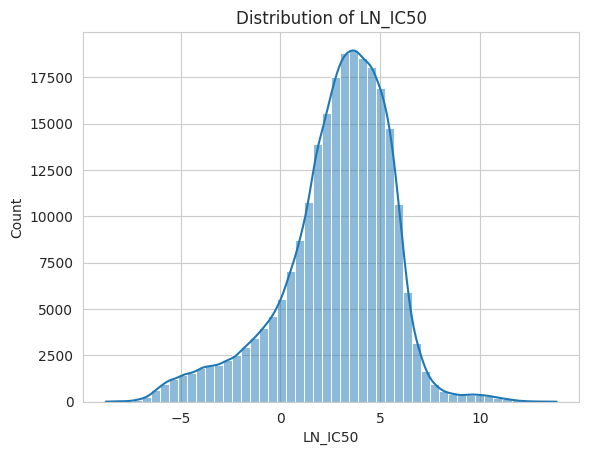

In [6]:
# Target variable
target = 'LN_IC50'

# check its distribution
if target in df.columns:
    sns.histplot(df[target], bins=50, kde=True)
    plt.title('Distribution of LN_IC50')
    plt.show()
else:
    print(f"Target column '{target}' not found. Available columns:", df.columns.tolist())

In [7]:
# Common identifier columns that should be dropped
cols_to_drop = [
    'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'SANGER_MODEL_ID',
    'COMPANY_ID', 'WEBRELEASE', 'DATASET', 'DRUG_ID'
]

# Keep only columns that exist
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']


In [8]:
X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (242035, 16)
Target shape: (242035,)


In [9]:
# Detect column types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['AUC', 'Z_SCORE']
Categorical features: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']


In [10]:
# Pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (193628, 16)
Test set size: (48407, 16)


In [12]:
# Fit the preprocessor on the training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing
try:
    feature_names = (numeric_features +
                     list(preprocessor.named_transformers_['cat']
                          .named_steps['onehot']
                          .get_feature_names_out(categorical_features)))
except:
    feature_names = [f'feature_{i}' for i in range(X_train_processed.shape[1])]

print("Processed training data shape:", X_train_processed.shape)

Processed training data shape: (193628, 1615)


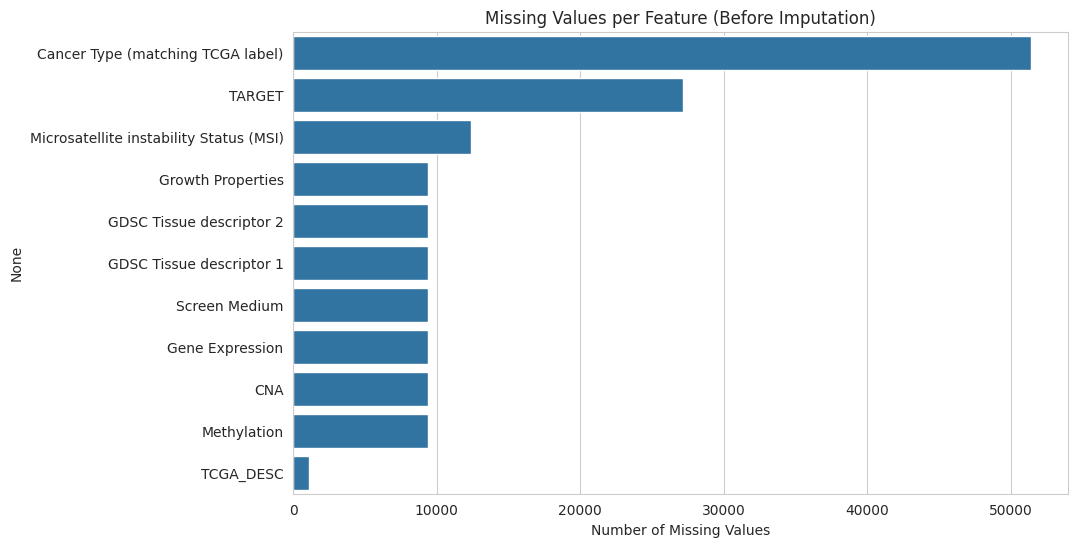

In [13]:
# Plot missing values in the original feature set (X)
missing_before = X.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

if not missing_before.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_before.values, y=missing_before.index)
    plt.title('Missing Values per Feature (Before Imputation)')
    plt.xlabel('Number of Missing Values')
    plt.show()
else:
    print("No missing values in the original data.")

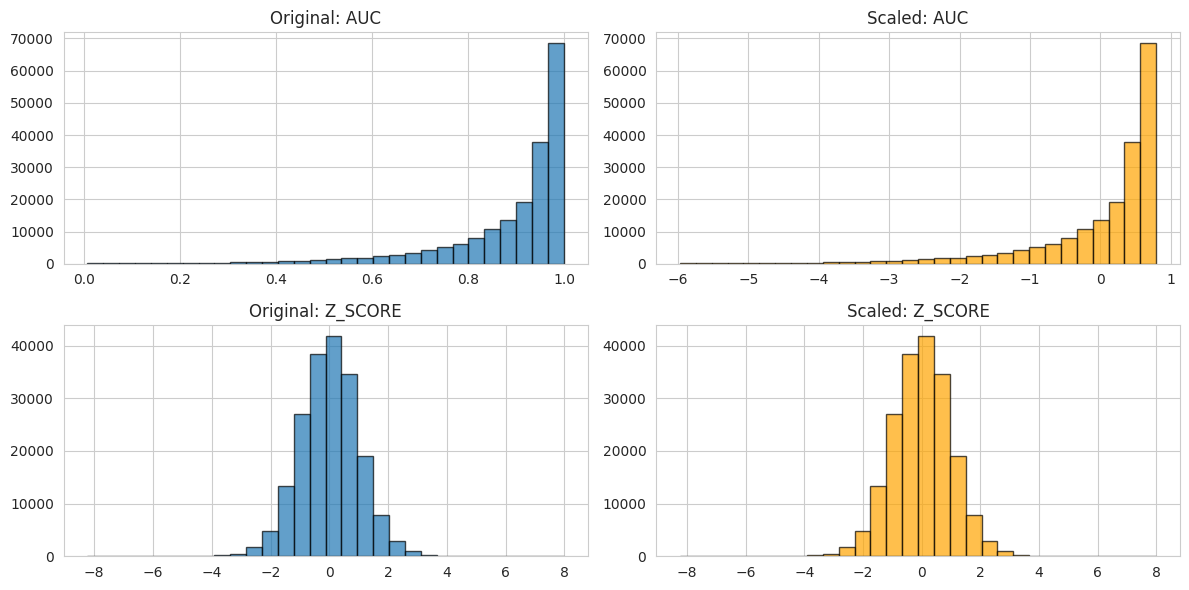

In [14]:
# Get list of numeric features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
n_features = len(numeric_features)

if n_features == 0:
    print("No numeric features found.")
else:
    # Create a figure with one row per feature, and 2 columns (original | scaled)
    fig, axes = plt.subplots(n_features, 2, figsize=(12, n_features * 3))

    # If only one feature, axes is 1D; make it 2D for consistent indexing
    if n_features == 1:
        axes = axes.reshape(1, -1)

    for i, feat in enumerate(numeric_features):
        # Original data (drop NaNs for clean plot)
        orig_vals = X_train[feat].dropna()
        # Scaled data (index in processed array)
        feat_idx = numeric_features.index(feat)
        scaled_vals = X_train_processed[:, feat_idx]

        # Original histogram (left column)
        axes[i, 0].hist(orig_vals, bins=30, edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'Original: {feat}')

        # Scaled histogram (right column)
        axes[i, 1].hist(scaled_vals, bins=30, edgecolor='black', alpha=0.7, color='orange')
        axes[i, 1].set_title(f'Scaled: {feat}')

    plt.tight_layout()
    plt.show()

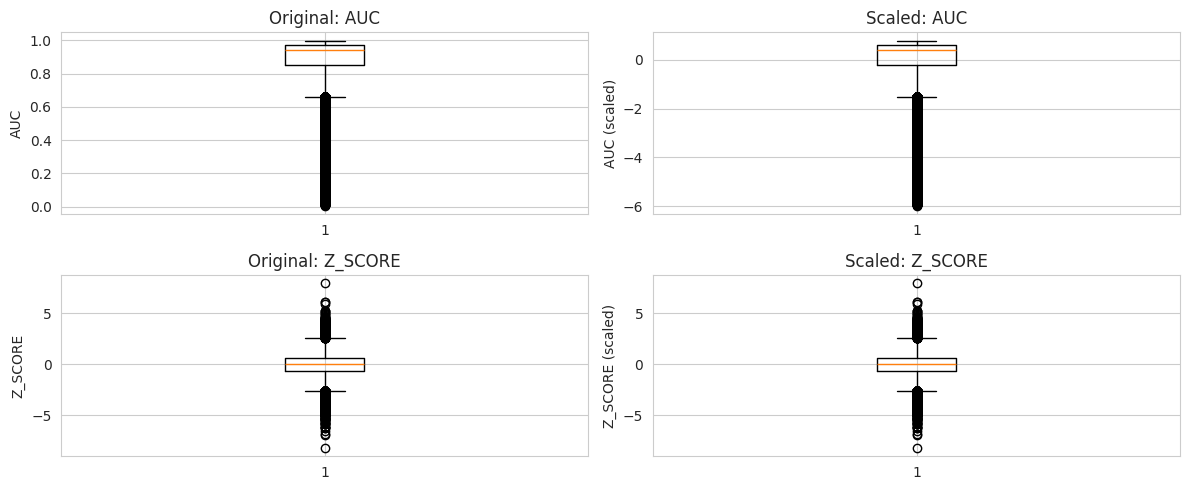

In [15]:
# Get list of numeric features (reuse from earlier)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
n_features = len(numeric_features)

if n_features == 0:
    print("No numeric features found.")
else:
    # Create a figure
    fig, axes = plt.subplots(n_features, 2, figsize=(12, n_features * 2.5))

    # Handle the case of a single feature
    if n_features == 1:
        axes = axes.reshape(1, -1)

    for i, feat in enumerate(numeric_features):
        # Original values (drop NaN for clean boxplot)
        orig_vals = X_train[feat].dropna()
        # Scaled values (index in processed array)
        feat_idx = numeric_features.index(feat)
        scaled_vals = X_train_processed[:, feat_idx]

        # Original boxplot (left)
        axes[i, 0].boxplot(orig_vals)
        axes[i, 0].set_title(f'Original: {feat}')
        axes[i, 0].set_ylabel(feat)

        # Scaled boxplot (right)
        axes[i, 1].boxplot(scaled_vals)
        axes[i, 1].set_title(f'Scaled: {feat}')
        axes[i, 1].set_ylabel(f'{feat} (scaled)')

    plt.tight_layout()
    plt.show()

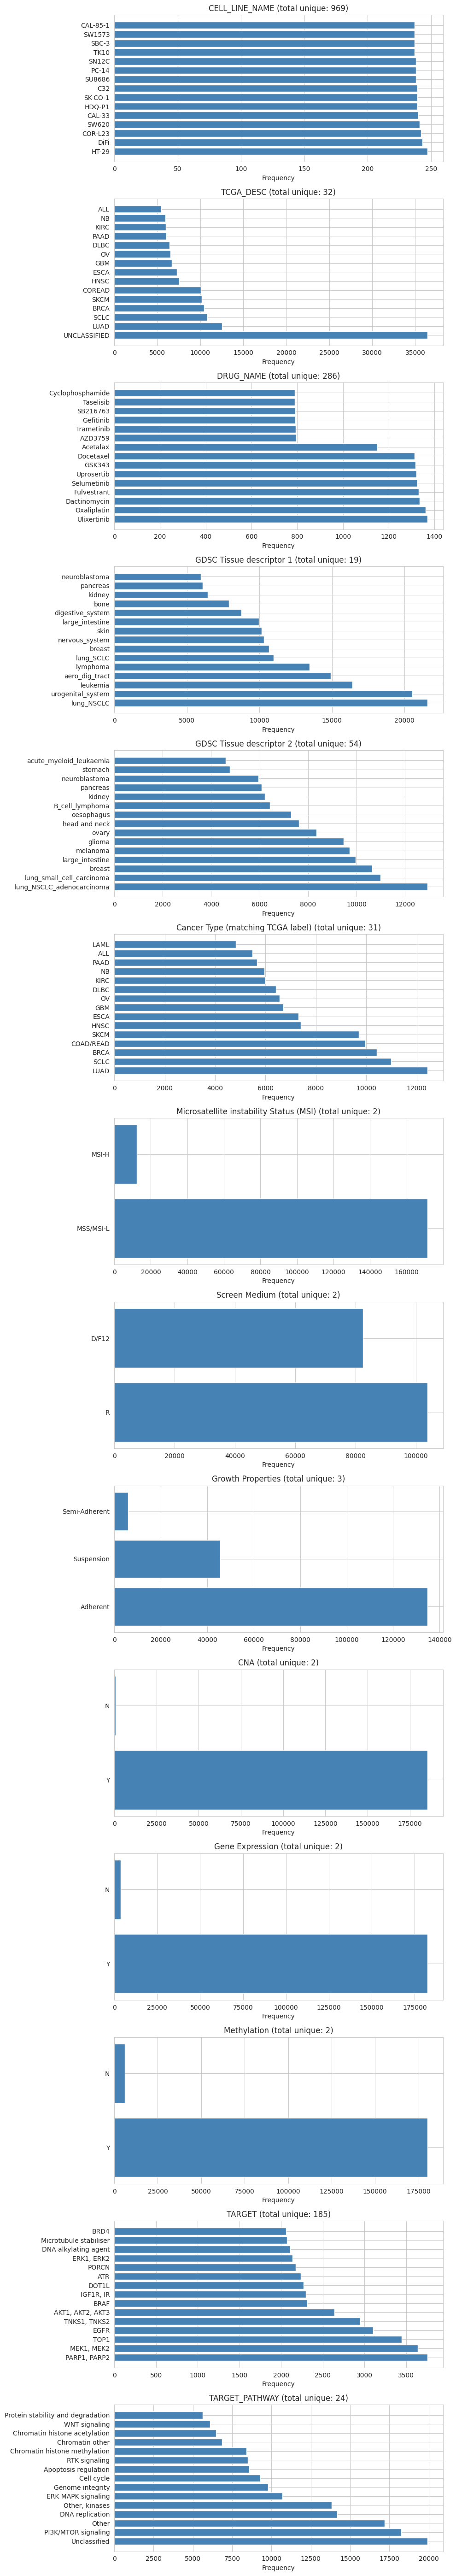


Categorical feature cardinalities:
CELL_LINE_NAME: 969 unique values
TCGA_DESC: 32 unique values
DRUG_NAME: 286 unique values
GDSC Tissue descriptor 1: 19 unique values
GDSC Tissue descriptor 2: 54 unique values
Cancer Type (matching TCGA label): 31 unique values
Microsatellite instability Status (MSI): 2 unique values
Screen Medium: 2 unique values
Growth Properties: 3 unique values
CNA: 2 unique values
Gene Expression: 2 unique values
Methylation: 2 unique values
TARGET: 185 unique values
TARGET_PATHWAY: 24 unique values


In [16]:
# Get list of categorical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
n_features = len(categorical_features)

if n_features == 0:
    print("No categorical features found.")
else:
    # Create a figure with one column, one row per feature
    fig, axes = plt.subplots(n_features, 1, figsize=(10, n_features * 4))

    # If only one feature, axes is a single Axes object; make it a list for looping
    if n_features == 1:
        axes = [axes]

    for i, feat in enumerate(categorical_features):
        # Top 15 most frequent categories
        top_cats = X_train[feat].value_counts().head(15)

        # Horizontal bar plot
        axes[i].barh(top_cats.index, top_cats.values, color='steelblue')
        axes[i].set_title(f'{feat} (total unique: {X_train[feat].nunique()})')
        axes[i].set_xlabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Print cardinalities as a quick reference
    print("\nCategorical feature cardinalities:")
    for feat in categorical_features:
        print(f"{feat}: {X_train[feat].nunique()} unique values")

In [18]:
# Summary
print("Preprocessing Summary:")
print(f"Original feature count: {X.shape[1]}")
print(f"Numeric features scaled to zero mean and unit variance.")
print(f"Categorical features one-hot encoded (unknown categories handled).")
print(f"Data split: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples.")

Preprocessing Summary:
Original feature count: 16
Numeric features scaled to zero mean and unit variance.
Categorical features one-hot encoded (unknown categories handled).
Data split: 193628 training samples, 48407 test samples.
